# 16 — Does a vimentin scar contain lesions? Day ~30 vs chronic peak

Suggestion from a collaborator: a successful astrocyte scar may be a good sign for recovery because it restricts
immune infiltration. Notebooks 11–12 found more lesion-astrocyte vimentin in milder / resolving disease. Here:

1. **Time.** Lesion borders at the chronic peak (PEAK1, d13–18) vs around day 30 post-induction: chronic MILD16 /
   SEVERE16 (d27–29) and RR PEAK2_MILD / PEAK2 / MONOPHASIC (d31–33). Does a vimentin border build between peak and
   d30, and does it differ by outcome?
2. **Containment.** Each lesion as an object: vimentin strength at its border, and how many infiltrating immune cells
   (T, B, NK/DC, DC, monocyte-derived macrophages, neutrophils; not microglia) sit just **outside** it relative to
   inside ("leakage"). The decisive comparison is **between lesions of the same animal** (same image, staining,
   disease stage): do better-bordered lesions leak less?
3. **The tissue**: the best- and worst-bordered lesion of one animal, side by side.

Lesion objects: control-referenced lesion cells (notebook 10) linked within 30 µm in the same tissue piece, ≥ 100
cells. Border band: −30 to +30 µm around the lesion edge. Perilesional zone: non-lesion cells 0–50 µm outside the
object. Image readouts use 18S-segmented cells ≥ 20 µm from another piece; vimentin as robust z within image.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/16_scar_containment.ipynb"
OUT = ROOT / "results" / "16_scar_containment"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125
IMMUNE = ["T cell", "B cell", "NK/DC", "DC", "MDM", "Neutrophil"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "day_of_sacrifice", "Anno_L1_curated",
             "x_centroid", "y_centroid"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet"))
obs["les"] = obs.lesion_state.str.startswith("S")
obs["immune"] = obs.ctype.isin(IMMUNE)
clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)

fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "segmentation_method", "smavim_cell_mean", "smavim_terr_mean",
                              "centroid_x_px", "centroid_y_px", "label"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]


def zimg(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


fa["vim_z"] = zimg(fa.smavim_cell_mean, fa.section_id)
fa["terr_vim_z"] = zimg(fa.smavim_terr_mean, fa.section_id)
obs = obs.join(fa[["vim_z", "terr_vim_z"]])

# cells < 20 µm from another tissue piece: excluded from image readouts (pieces touch in runs 1-3)
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m])[0]
obs.loc[other < 20, ["vim_z", "terr_vim_z"]] = np.nan
print(len(obs), "cells")

1384881 cells


## Lesion objects and their borders

In [3]:
rows = []
cell_obj = pd.Series(-1, index=obs.index)
cell_dist = pd.Series(np.nan, index=obs.index)  # signed: + inside, - outside
for pc, g in obs[obs.lesion_state != "not scored"].groupby("meta_sample_id", observed=True):
    L, N = g[g.les], g[~g.les]
    if len(L) < 100 or len(N) < 100:
        continue
    xyL, xyN = L[["x_centroid", "y_centroid"]].to_numpy(), N[["x_centroid", "y_centroid"]].to_numpy()
    pairs = cKDTree(xyL).query_pairs(30.0, output_type="ndarray")
    _, lab = connected_components(coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                                             shape=(len(L), len(L))), directed=False)
    size = np.bincount(lab)
    keep = size[lab] >= 100
    lab_id = np.array([f"{pc}#{x}" for x in lab])
    cell_obj[L.index[keep]] = lab_id[keep]
    cell_dist[L.index] = cKDTree(xyN).query(xyL)[0]          # depth inside
    dN, iL = cKDTree(xyL).query(xyN)                           # outside: distance to nearest lesion cell
    cell_dist[N.index] = -dN
    near = (dN <= 50) & keep[iL]
    cell_obj[N.index[near]] = lab_id[iL[near]]                 # perilesional cells belong to the nearest object
obs["obj"], obs["edge_um"] = cell_obj, cell_dist

o = obs[obs.obj != -1]
inside = o.les
band = o.edge_um.between(-30, 30)
ast = o.Anno_L1_curated == "Astrocyte"
g_in, g_out = o[inside].groupby("obj"), o[~inside].groupby("obj")
objs = pd.DataFrame({
    "sample_name": o.groupby("obj").sample_name.first(),
    "size": g_in.size(),
    "active share": g_in.lesion_state.agg(lambda s: s.str[:2].isin(["S1", "S4"]).mean()),
    "immune inside": g_in.immune.mean(),
    "immune outside (0–50 µm)": g_out.immune.mean(),
    "n outside": g_out.size(),
    "border astro vimentin": o[band & ast].groupby("obj").vim_z.median(),
    "n border astro": o[band & ast].groupby("obj").vim_z.count(),
    "border tissue vimentin": o[band].groupby("obj").terr_vim_z.median(),
    "core astro vimentin": o[(o.edge_um > 60) & ast].groupby("obj").vim_z.median(),
})
objs["leakage"] = np.log2((objs["immune outside (0–50 µm)"] + 0.005) / (objs["immune inside"] + 0.005))
an = obs.groupby("sample_name", observed=True).agg(stage=("stage", "first"), arm=("arm", "first"),
                                                   day=("day_of_sacrifice", "first"))
objs = objs.join(an, on="sample_name").join(clin[["score", "first_peak"]], on="sample_name")
objs = objs[(objs["n outside"] >= 30)]
objs.to_csv(OUT / "lesion_objects.csv")
print(len(objs), "lesion objects in", objs.sample_name.nunique(), "animals")
objs.describe().T[["50%", "min", "max"]].round(3)

/tmp/ipykernel_62606/1543832729.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['C2_G1_Bot_0#0' 'C2_G1_Bot_0#1' 'C2_G1_Bot_0#1' ... 'C2_G1_Bot_0#1'
 'C2_G1_Bot_0#1' 'C2_G1_Bot_0#1']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cell_obj[L.index[keep]] = lab_id[keep]


419 lesion objects in 53 animals


,50%,min,max
size,311.000,100.000,15890.000
active share,0.167,0.000,0.807
immune inside,0.178,0.008,0.573
immune outside (0–50 µm),0.033,0.000,0.147
n outside,100.000,30.000,1433.000
border astro vimentin,1.686,-1.429,36.727
n border astro,17.000,1.000,335.000
border tissue vimentin,0.285,-2.058,22.573
core astro vimentin,2.334,-2.552,39.687
leakage,-2.199,-6.575,1.268


## 1. Day ~30 vs chronic peak
Per animal: median over its lesion objects (size-weighted where noted) of border astrocyte vimentin, border tissue
vimentin and leakage.

In [4]:
GROUP30 = {"chronic PEAK1 (d13–18)": lambda d: (d.stage == "PEAK1") & (d.arm == "chronic"),
           "RR PEAK1 (d14–18)": lambda d: (d.stage == "PEAK1") & (d.arm == "RR"),
           "MILD16 (d27–28)": lambda d: d.stage == "MILD16", "SEVERE16 (d28–29)": lambda d: d.stage == "SEVERE16",
           "PEAK2_MILD (d31)": lambda d: d.stage == "PEAK2_MILD", "PEAK2 (d32–33)": lambda d: d.stage == "PEAK2",
           "MONOPHASIC (d32–33)": lambda d: d.stage == "MONOPHASIC"}
pa = objs.groupby("sample_name").apply(lambda g: pd.Series({
    "border astro vimentin": np.average(g["border astro vimentin"].fillna(g["border astro vimentin"].median()),
                                        weights=g["size"]) if g["border astro vimentin"].notna().any() else np.nan,
    "border tissue vimentin": np.average(g["border tissue vimentin"].fillna(0), weights=g["size"]),
    "leakage": np.average(g.leakage, weights=g["size"]),
    "immune outside (0–50 µm)": np.average(g["immune outside (0–50 µm)"], weights=g["size"]),
    "objects": len(g)}), include_groups=False).join(an).join(clin[["score"]])
pa.to_csv(OUT / "per_animal.csv")
rows = []
for gname, f in GROUP30.items():
    d = pa[f(pa)]
    rows.append({"group": gname, "animals": len(d), **d[["border astro vimentin", "border tissue vimentin", "leakage",
                                                          "immune outside (0–50 µm)", "objects"]].median().to_dict()})
tab30 = pd.DataFrame(rows).set_index("group")
tab30.round(3)

,animals,border astro vimentin,border tissue vimentin,leakage,immune outside (0–50 µm),objects
group,,,,,,
chronic PEAK1 (d13–18),6,0.583,0.038,-3.596,0.028,4.0
RR PEAK1 (d14–18),4,0.005,-0.173,-4.117,0.019,3.5
MILD16 (d27–28),3,2.646,0.968,-1.541,0.046,4.0
SEVERE16 (d28–29),3,0.758,0.017,-2.154,0.043,9.0
PEAK2_MILD (d31),2,3.836,0.626,-2.457,0.044,19.0
PEAK2 (d32–33),2,1.223,0.295,-3.230,0.033,7.0
MONOPHASIC (d32–33),4,5.041,2.913,-2.387,0.049,9.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/day30_vs_peak.png')

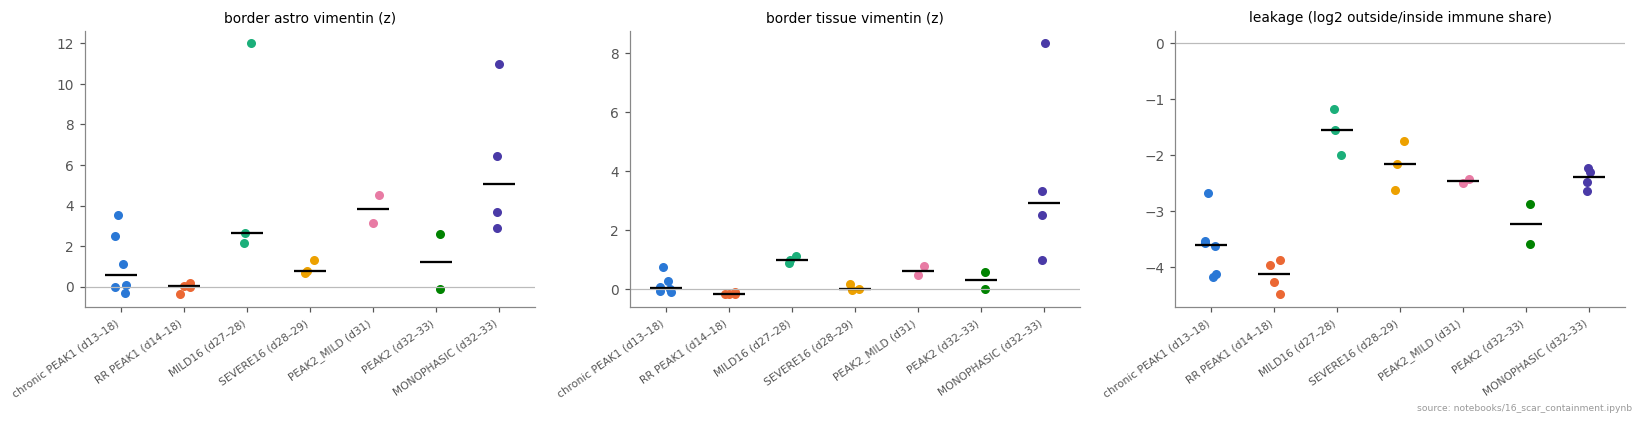

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c in zip(axs, ["border astro vimentin", "border tissue vimentin", "leakage"]):
    for k, (gname, f) in enumerate(GROUP30.items()):
        v = pa[f(pa)][c].dropna()
        ax.scatter(np.full(len(v), k) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), v, s=24,
                   color=COL[k % 8])
        ax.hlines(v.median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.set_xticks(range(len(GROUP30)), list(GROUP30), rotation=35, ha="right", fontsize=7)
    ax.axhline(0, color="#bbbbbb", lw=0.8)
    ax.set_title(c + (" (log2 outside/inside immune share)" if c == "leakage" else " (z)"), fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "day30_vs_peak", OUT, SRC)

In [6]:
cmp = []
for a_, b_ in [("chronic PEAK1 (d13–18)", "MILD16 (d27–28)"), ("chronic PEAK1 (d13–18)", "SEVERE16 (d28–29)"),
               ("MILD16 (d27–28)", "SEVERE16 (d28–29)"), ("MONOPHASIC (d32–33)", "PEAK2 (d32–33)"),
               ("MONOPHASIC (d32–33)", "PEAK2_MILD (d31)"), ("RR PEAK1 (d14–18)", "MONOPHASIC (d32–33)")]:
    for c in ["border astro vimentin", "border tissue vimentin", "leakage"]:
        x, y = pa[GROUP30[a_](pa)][c].dropna(), pa[GROUP30[b_](pa)][c].dropna()
        if len(x) >= 2 and len(y) >= 2:
            cmp.append(dict(a=a_, b=b_, measure=c, med_a=x.median(), med_b=y.median(), n=f"{len(x)}+{len(y)}",
                            p=mannwhitneyu(x, y).pvalue))
pd.DataFrame(cmp).round(3)

,a,b,measure,med_a,med_b,n,p
0,chronic PEAK1 (d13–18),MILD16 (d27–28),border astro vimentin,0.583,2.646,6+3,0.167
1,chronic PEAK1 (d13–18),MILD16 (d27–28),border tissue vimentin,0.038,0.968,6+3,0.024
2,chronic PEAK1 (d13–18),MILD16 (d27–28),leakage,-3.596,-1.541,6+3,0.024
3,chronic PEAK1 (d13–18),SEVERE16 (d28–29),border astro vimentin,0.583,0.758,6+3,0.905
4,chronic PEAK1 (d13–18),SEVERE16 (d28–29),border tissue vimentin,0.038,0.017,6+3,1.000
5,chronic PEAK1 (d13–18),SEVERE16 (d28–29),leakage,-3.596,-2.154,6+3,0.024
6,MILD16 (d27–28),SEVERE16 (d28–29),border astro vimentin,2.646,0.758,3+3,0.100
7,MILD16 (d27–28),SEVERE16 (d28–29),border tissue vimentin,0.968,0.017,3+3,0.100
8,MILD16 (d27–28),SEVERE16 (d28–29),leakage,-1.541,-2.154,3+3,0.200
9,MONOPHASIC (d32–33),PEAK2 (d32–33),border astro vimentin,5.041,1.223,4+2,0.133


## 2. Containment: across lesions of the same animal
For every animal with ≥ 5 lesion objects (that have border astrocytes): Spearman ρ between border vimentin and
leakage across its lesions. Negative ρ = better-bordered lesions leak fewer immune cells. Then the same after
removing, within each animal, what lesion size and activity (share of active S1/S4 tissue) explain.

In [7]:
def within_animal(df, x, y, adjust=False, min_obj=5):
    out = {}
    for an_, g in df.groupby("sample_name"):
        g = g[[x, y, "size", "active share"]].dropna()
        if len(g) < min_obj:
            continue
        xx, yy = g[x].to_numpy(), g[y].to_numpy()
        if adjust:
            Z = np.c_[np.ones(len(g)), np.log(g["size"]), g["active share"]]
            xx = xx - Z @ np.linalg.lstsq(Z, xx, rcond=None)[0]
            yy = yy - Z @ np.linalg.lstsq(Z, yy, rcond=None)[0]
        out[an_] = spearmanr(xx, yy).statistic
    return pd.Series(out)


rows = []
for x in ["border astro vimentin", "border tissue vimentin"]:
    for adj in (False, True):
        r = within_animal(objs, x, "leakage", adj).dropna()
        rows.append(dict(border=x, adjusted_for_size_and_activity=adj, animals=len(r), median_rho=r.median(),
                         share_negative=(r < 0).mean(), wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
        if x == "border tissue vimentin" and adj:
            rho_tissue_adj = r
cont = pd.DataFrame(rows)
cont.to_csv(OUT / "within_animal_containment.csv", index=False)
cont.round(3)

,border,adjusted_for_size_and_activity,animals,median_rho,share_negative,wilcoxon_p
0,border astro vimentin,False,37,0.143,0.324,0.014
1,border astro vimentin,True,37,0.093,0.459,0.281
2,border tissue vimentin,False,37,0.200,0.297,0.002
3,border tissue vimentin,True,37,0.214,0.378,0.046


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/within_animal_containment.png')

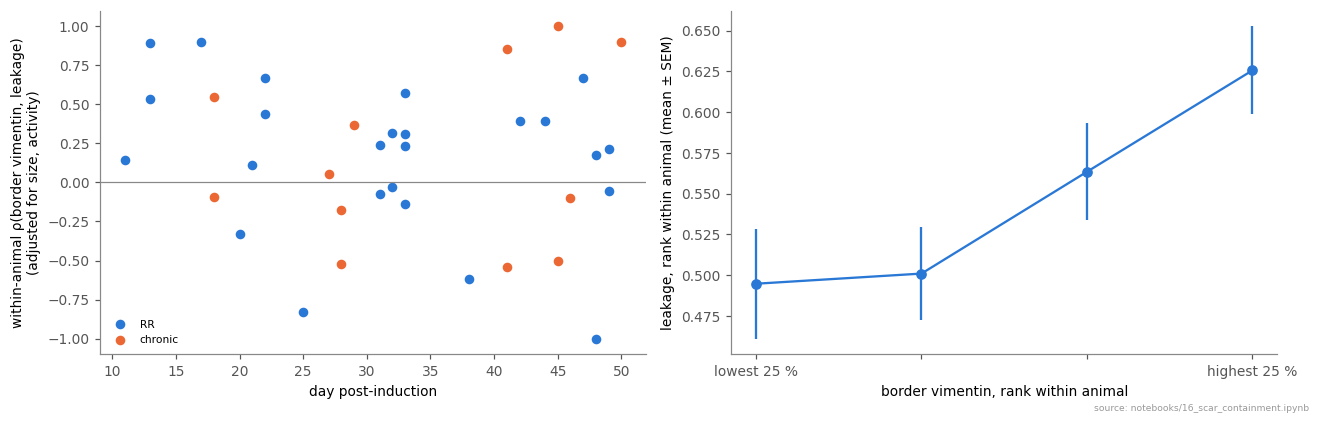

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
r = within_animal(objs, "border tissue vimentin", "leakage", True).dropna().to_frame("rho").join(an)
for k, (arm, g) in enumerate(r.groupby("arm")):
    axs[0].scatter(g.day, g.rho, s=28, color=COL[k], label=arm)
axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set(xlabel="day post-induction", ylabel="within-animal ρ(border vimentin, leakage)\n(adjusted for size, activity)")
axs[0].legend(fontsize=7)
# pooled view: within-animal ranks
oo = objs.dropna(subset=["border tissue vimentin", "leakage"]).copy()
oo["vim_rank"] = oo.groupby("sample_name")["border tissue vimentin"].rank(pct=True)
oo["leak_rank"] = oo.groupby("sample_name")["leakage"].rank(pct=True)
oo = oo[oo.groupby("sample_name").leakage.transform("size") >= 5]
bins = pd.cut(oo.vim_rank, [0, 0.25, 0.5, 0.75, 1.0])
m = oo.groupby(bins, observed=True).leak_rank.agg(["mean", "sem"])
axs[1].errorbar(range(4), m["mean"], m["sem"], marker="o", color=COL[0])
axs[1].set_xticks(range(4), ["lowest 25 %", "", "", "highest 25 %"])
axs[1].set(xlabel="border vimentin, rank within animal", ylabel="leakage, rank within animal (mean ± SEM)")
fig.tight_layout()
plotting.save_fig(fig, "within_animal_containment", OUT, SRC)

## 3. The tissue: best- vs worst-bordered lesion of one animal
A day ~30 animal (MILD16 / SEVERE16 / PEAK2 / PEAK2_MILD / MONOPHASIC) with the largest within-animal spread of
border vimentin among lesions ≥ 300 cells in one piece. Left: αSMA/vimentin channel (magma, same image, same
contrast); right: lesion cells (light) and infiltrating immune cells (red), lesion edge band (cyan).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/best_vs_worst_bordered_lesion.png')

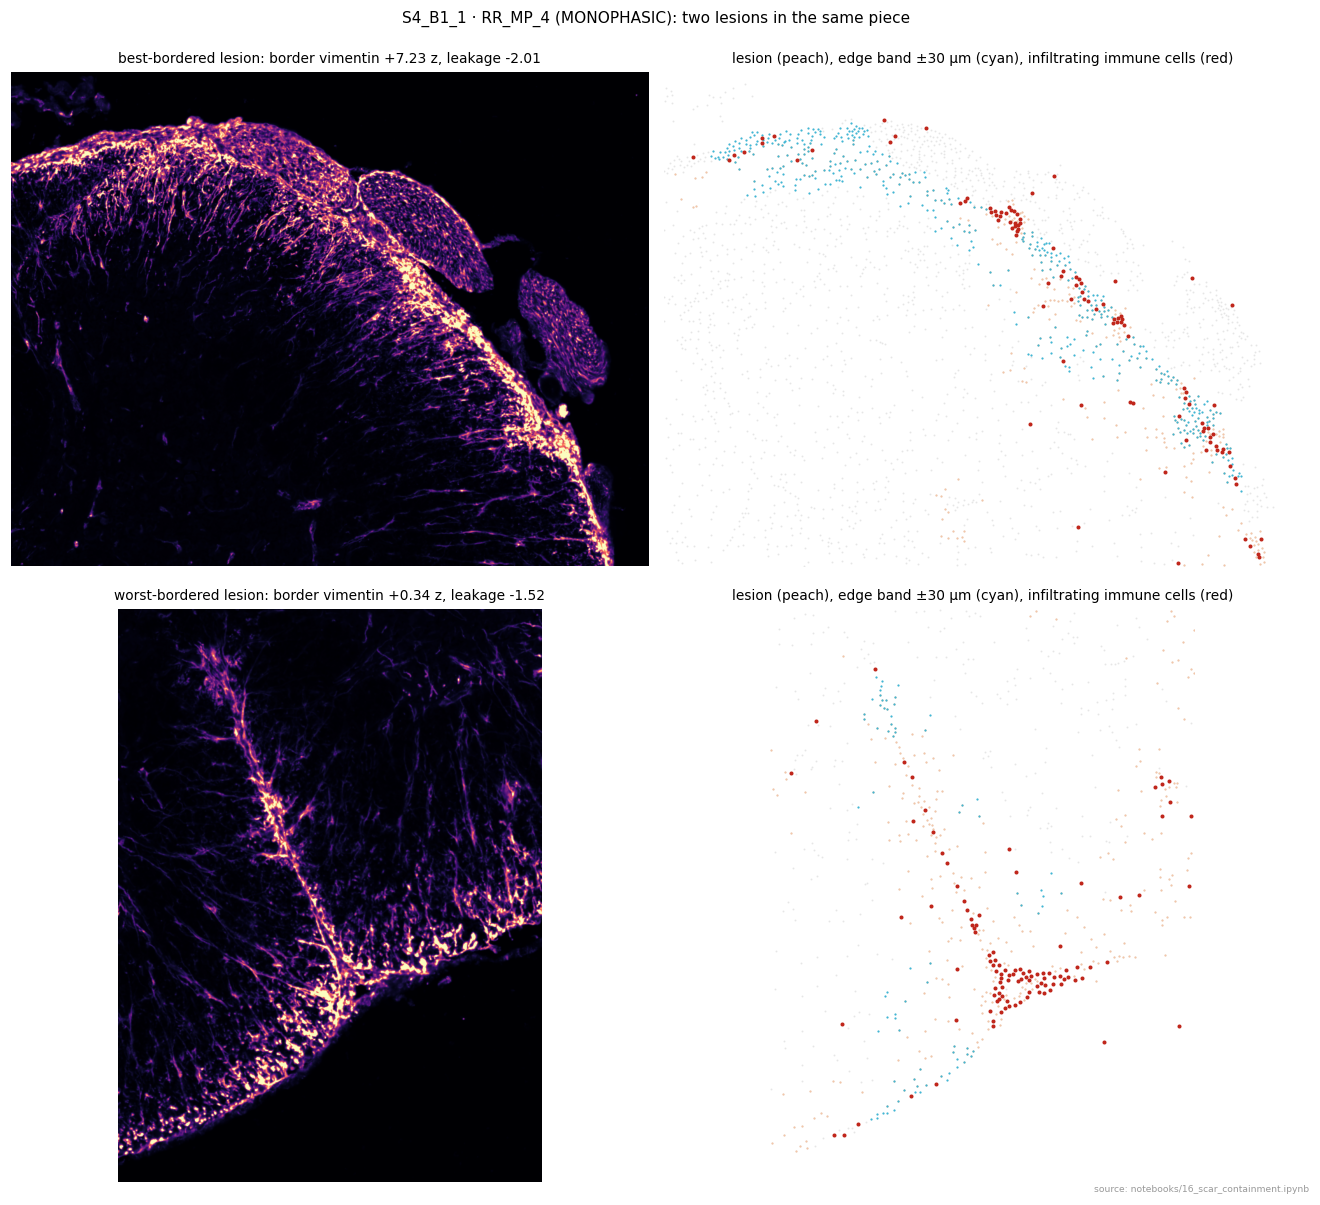

In [9]:
bundles = find_bundles(data.load_config())
d30 = objs[objs.stage.isin(["MILD16", "SEVERE16", "PEAK2", "PEAK2_MILD", "MONOPHASIC"]) & (objs["size"] >= 300)]
d30 = d30.dropna(subset=["border tissue vimentin"])
d30 = d30.assign(piece=d30.index.str.split("#").str[0])
spread = d30.groupby("piece")["border tissue vimentin"].agg(lambda s: s.max() - s.min() if len(s) >= 2 else np.nan)
piece = spread.idxmax()
cand = d30[d30.piece == piece]
hi_o, lo_o = cand["border tissue vimentin"].idxmax(), cand["border tissue vimentin"].idxmin()
sec = obs[obs.meta_sample_id == piece].sample_id.iloc[0]
b = XeniumBundle(bundles[str(sec)])
lv, f = 2, 2 ** 2
vim_img = b.read_level("smavim", lv)
hiv = np.percentile(vim_img[vim_img > 0], 99.7)
fig, axs = plt.subplots(2, 2, figsize=(12, 11))
for row, ob in enumerate([hi_o, lo_o]):
    c = obs[obs.obj == ob]
    pad = 80
    x0, x1 = c.x_centroid.min() - pad, c.x_centroid.max() + pad
    y0, y1 = c.y_centroid.min() - pad, c.y_centroid.max() + pad
    sl = (slice(int(y0 / (PX * f)), int(y1 / (PX * f))), slice(int(x0 / (PX * f)), int(x1 / (PX * f))))
    axs[row, 0].imshow(np.clip(vim_img[sl] / hiv, 0, 1), cmap="magma", extent=(x0, x1, y1, y0))
    axs[row, 0].set_title(f"{'best' if row == 0 else 'worst'}-bordered lesion: border vimentin "
                          f"{objs.loc[ob, 'border tissue vimentin']:+.2f} z, leakage {objs.loc[ob, 'leakage']:+.2f}",
                          fontsize=9)
    w = obs[(obs.meta_sample_id == piece) & obs.x_centroid.between(x0, x1) & obs.y_centroid.between(y0, y1)]
    ax = axs[row, 1]
    ax.scatter(w.x_centroid, w.y_centroid, s=1.5, color="#e6e6e6", lw=0)
    ax.scatter(w[w.les].x_centroid, w[w.les].y_centroid, s=2, color="#f3c6a8", lw=0)
    bb = w[(w.obj == ob) & w.edge_um.between(-30, 30)]
    ax.scatter(bb.x_centroid, bb.y_centroid, s=2, color="#3fb8d6", lw=0)
    im_ = w[w.immune]
    ax.scatter(im_.x_centroid, im_.y_centroid, s=7, color="#c0261b", lw=0)
    ax.set_xlim(x0, x1); ax.set_ylim(y1, y0); ax.set_aspect("equal")
    ax.set_title("lesion (peach), edge band ±30 µm (cyan), infiltrating immune cells (red)", fontsize=9)
    for a_ in axs[row]:
        a_.axis("off")
fig.suptitle(f"{piece} · {objs.loc[hi_o, 'sample_name']} ({objs.loc[hi_o, 'stage']}): two lesions in the same piece",
             fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "best_vs_worst_bordered_lesion", OUT, SRC)

## 2b. A fairer containment test
The leakage ratio (outside ÷ inside immune share) rises when a lesion empties of immune cells while resolving, even
if nothing escapes, and vimentin is highest in resolving lesions; so the ratio confounds "leaky" with "resolving".
Three better measures:

- **Escape**: immune share 0–50 µm outside the lesion relative to the same animal's distant healthy tissue
  (> 150 µm from any lesion): log2 ratio; 0 = no excess immune cells around the lesion.
- **Edge spike** (vimentin ring, notebook 15): tissue vimentin 0–10 µm inside the edge minus the mean of
  −30…−10 µm (outside) and +20…+45 µm (inside).
- **Immune profile across the edge**, for each animal's lesions split at its median edge spike.

In [10]:
far = obs[obs.edge_um < -150].groupby("sample_name", observed=True).immune.mean()
objs["escape"] = np.log2((objs["immune outside (0–50 µm)"] + 0.002) / (objs.sample_name.map(far) + 0.002))
o = obs[obs.obj != -1]
z0 = o[o.edge_um.between(0, 10, inclusive="right")].groupby("obj").terr_vim_z.median()
zo = o[o.edge_um.between(-30, -10)].groupby("obj").terr_vim_z.median()
zi = o[o.edge_um.between(20, 45)].groupby("obj").terr_vim_z.median()
objs["edge spike"] = z0 - (zo + zi) / 2
objs.to_csv(OUT / "lesion_objects.csv")

rows = []
for x in ["edge spike", "border tissue vimentin", "border astro vimentin"]:
    for y in ["escape", "immune outside (0–50 µm)"]:
        for adj in (False, True):
            r = within_animal(objs, x, y, adj).dropna()
            rows.append(dict(border=x, outcome=y, adjusted=adj, animals=len(r), median_rho=r.median(),
                             share_negative=(r < 0).mean(), wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
cont2 = pd.DataFrame(rows)
cont2.to_csv(OUT / "within_animal_containment_v2.csv", index=False)
cont2.round(3)

,border,outcome,adjusted,animals,median_rho,share_negative,wilcoxon_p
0,edge spike,escape,False,37,0.300,0.378,0.008
1,edge spike,escape,True,37,0.200,0.243,0.029
2,edge spike,immune outside (0–50 µm),False,37,0.300,0.378,0.008
3,edge spike,immune outside (0–50 µm),True,37,0.200,0.324,0.054
4,border tissue vimentin,escape,False,37,0.386,0.216,0.000
5,border tissue vimentin,escape,True,37,0.420,0.189,0.000
6,border tissue vimentin,immune outside (0–50 µm),False,37,0.386,0.216,0.000
7,border tissue vimentin,immune outside (0–50 µm),True,37,0.381,0.216,0.001
8,border astro vimentin,escape,False,37,0.452,0.135,0.000
9,border astro vimentin,escape,True,37,0.300,0.189,0.006


In [11]:
# per animal: edge spike (size-weighted) by group
pa["edge spike"] = objs.groupby("sample_name").apply(
    lambda g: np.average(g["edge spike"].fillna(0), weights=g["size"]), include_groups=False)
pa["escape"] = objs.groupby("sample_name").apply(lambda g: np.average(g.escape, weights=g["size"]),
                                                 include_groups=False)
pd.DataFrame({gname: pa[f(pa)][["edge spike", "escape"]].median() for gname, f in GROUP30.items()}).T.round(2)

,edge spike,escape
chronic PEAK1 (d13–18),0.21,0.18
RR PEAK1 (d14–18),0.26,2.90
MILD16 (d27–28),0.97,2.27
SEVERE16 (d28–29),0.00,2.29
PEAK2_MILD (d31),1.74,2.35
PEAK2 (d32–33),1.24,-0.20
MONOPHASIC (d32–33),4.55,2.27


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/16_scar_containment/immune_profile_by_edge_vimentin.png')

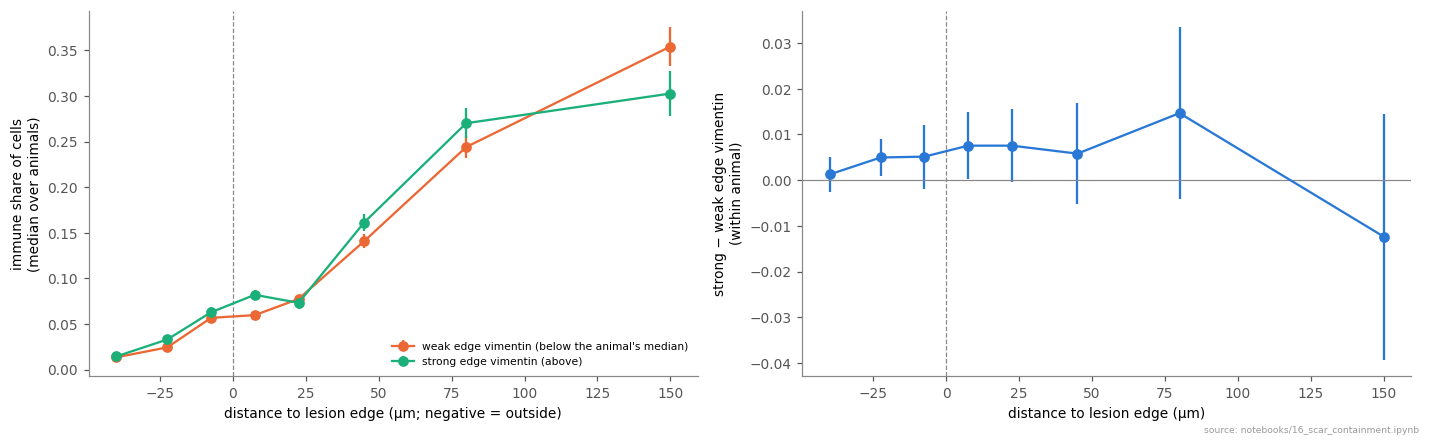

In [12]:
EB = [-150, -100, -70, -50, -30, -15, 0, 15, 30, 60, 100, 200]
o = obs[obs.obj.isin(objs.index)].copy()
o["edge_bin"] = pd.cut(o.edge_um, EB)
o = o.join(objs[["edge spike", "sample_name"]].rename(columns={"sample_name": "_an"}), on="obj")
o["spike_hi"] = o.groupby("_an")["edge spike"].transform(lambda s: s > s.median())
prof = o.groupby(["_an", "spike_hi", "edge_bin"], observed=True).immune.mean().unstack("edge_bin").reindex(
    columns=o.edge_bin.cat.categories)
mids = [(a_ + b_) / 2 for a_, b_ in zip(EB[:-1], EB[1:])]
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for k, (lab, c) in enumerate([("weak edge vimentin (below the animal's median)", COL[1]),
                              ("strong edge vimentin (above)", COL[2])]):
    p = prof.xs(k == 1, level="spike_hi")
    axs[0].errorbar(mids, p.median(), yerr=p.sem(), marker="o", color=c, label=lab)
axs[0].axvline(0, color="#888888", ls="--", lw=0.8)
axs[0].set(xlabel="distance to lesion edge (µm; negative = outside)", ylabel="immune share of cells\n(median over animals)")
axs[0].legend(fontsize=7)
diff = (prof.xs(True, level="spike_hi") - prof.xs(False, level="spike_hi"))
axs[1].errorbar(mids, diff.median(), yerr=diff.sem(), marker="o", color=COL[0])
axs[1].axhline(0, color="#888888", lw=0.8); axs[1].axvline(0, color="#888888", ls="--", lw=0.8)
axs[1].set(xlabel="distance to lesion edge (µm)", ylabel="strong − weak edge vimentin\n(within animal)")
fig.tight_layout()
plotting.save_fig(fig, "immune_profile_by_edge_vimentin", OUT, SRC)

## 2c. Surface confound: deep lesions only
The best-bordered lesion above runs along the cord surface, where vimentin is naturally high (glia limitans,
astrocyte end-feet at the pia) and immune cells enter from the meninges. So border vimentin and immune cells around a
lesion can both just reflect closeness to the surface. Repeat the within-animal tests (i) on lesions whose cells
lie a median > 100 µm from the tissue edge, and (ii) on all lesions with that depth as an extra covariate.

In [13]:
pia = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=["edge_um"]).edge_um.rename("pia_um")
obs = obs.join(pia)
objs["lesion depth from surface (µm)"] = obs[obs.les & (obs.obj != -1)].groupby("obj").pia_um.median()


def within_animal_depth(df, x, y, min_obj=5):
    out = {}
    for an_, g in df.groupby("sample_name"):
        g = g[[x, y, "size", "active share", "lesion depth from surface (µm)"]].dropna()
        if len(g) < min_obj:
            continue
        Z = np.c_[np.ones(len(g)), np.log(g["size"]), g["active share"], np.log1p(g["lesion depth from surface (µm)"])]
        xx = g[x].to_numpy() - Z @ np.linalg.lstsq(Z, g[x].to_numpy(), rcond=None)[0]
        yy = g[y].to_numpy() - Z @ np.linalg.lstsq(Z, g[y].to_numpy(), rcond=None)[0]
        out[an_] = spearmanr(xx, yy).statistic
    return pd.Series(out)


deep = objs[objs["lesion depth from surface (µm)"] > 100]
print(f"deep lesions: {len(deep)} of {len(objs)}")
rows = []
for x in ["edge spike", "border tissue vimentin", "border astro vimentin"]:
    for lab, r in [("deep lesions only (adj. size, activity)", within_animal(deep, x, "escape", True, min_obj=4)),
                   ("all lesions, adj. size, activity, depth", within_animal_depth(objs, x, "escape"))]:
        r = r.dropna()
        rows.append(dict(border=x, analysis=lab, animals=len(r), median_rho=r.median(), share_negative=(r < 0).mean(),
                         wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
cont3 = pd.DataFrame(rows)
cont3.to_csv(OUT / "within_animal_containment_depth.csv", index=False)
cont3.round(3)

deep lesions: 243 of 419


,border,analysis,animals,median_rho,share_negative,wilcoxon_p
0,edge spike,"deep lesions only (adj. size, activity)",30,0.236,0.367,0.270
1,edge spike,"all lesions, adj. size, activity, depth",37,0.193,0.351,0.451
2,border tissue vimentin,"deep lesions only (adj. size, activity)",30,0.312,0.267,0.031
3,border tissue vimentin,"all lesions, adj. size, activity, depth",37,0.253,0.243,0.003
4,border astro vimentin,"deep lesions only (adj. size, activity)",30,0.446,0.233,0.041
5,border astro vimentin,"all lesions, adj. size, activity, depth",37,0.254,0.324,0.154


In [14]:
print("does depth drive both? across all lesions:",
      {c: round(spearmanr(np.log1p(objs['lesion depth from surface (µm)']), objs[c], nan_policy='omit').statistic, 2)
       for c in ["border tissue vimentin", "edge spike", "escape"]})

does depth drive both? across all lesions: {'border tissue vimentin': np.float64(-0.44), 'edge spike': np.float64(-0.22), 'escape': np.float64(-0.34)}


## Findings

> **Finding — the vimentin border builds between the chronic peak and day ~30, but only in milder animals.** Border
> tissue vimentin per animal: chronic PEAK1 0.04 → MILD16 0.97 (p = 0.02) but SEVERE16 0.02 (no change); border
> astrocyte vimentin 0.58 → 2.65 (MILD16) vs 0.76 (SEVERE16). At d31–33 never-relapsing MONOPHASIC animals have the
> strongest borders (tissue 2.91, astrocyte 5.04) vs PEAK2 0.30 / 1.22 and PEAK2_MILD 0.63 / 3.84; RR PEAK1 → MONOPHASIC
> rises (p = 0.03). So a scar-like vimentin border forms by d30 in animals that do well, and not in those that stay
> severe or relapse. Small groups (2–6 animals).
>
> **Finding — but in a snapshot it does not look like containment.** Comparing lesions *within the same animal*,
> better vimentin-bordered lesions have **more**, not fewer, infiltrating immune cells just outside them (escape vs the
> animal's distant healthy tissue: ρ +0.3 to +0.45, p < 0.01; immune profile across the edge slightly higher for
> strong-border lesions). Lesions near the cord surface have both more vimentin (glia limitans) and more immune cells
> (meningeal entry), but on deep lesions only (> 100 µm from the surface) and with depth as a covariate, border tissue
> vimentin still goes with more immune cells around the lesion (ρ +0.25 to +0.31, p = 0.003–0.03). The best reading:
> reactive astrocytes build their vimentin border **where immune cells are active at the lesion edge**, a response
> to the infiltrate. Whether that border then restricts further spread can't be decided from single time points:
> the animal-level pattern (borders form in milder animals) fits a protective role, the lesion-level pattern fits a
> response. Testing it would need time-resolved data (e.g. serial imaging, or an intervention on astrocyte
> reactivity).